#### Pytorch computer vision

In [1]:
## 0. Computer vision libraries

import torch 
from torch import nn 

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)



2.5.1+cpu
0.20.1+cpu


#### 1. Getting a Dataset

In [2]:
# Training Data
from torchvision import datasets
train_data = datasets.FashionMNIST(
    root = "data" , 
    train = True, # If we want the training data
    download = True, 
    transform = ToTensor() , # How do we want to transform the data
    target_transform = None  # How do we want to transform the labels/targets
)

test_data = datasets.FashionMNIST (
    root = "data" , 
    train = False , 
    download = True , 
    transform = ToTensor () , 
    target_transform = None 
    
)

In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
# See training example

image , label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [7]:
# Check shape

print(f' image shape : {image.shape} -> [color_channels, height, width]')
print(f' Image label : {class_names[label]}')

 image shape : torch.Size([1, 28, 28]) -> [color_channels, height, width]
 Image label : Ankle boot


#### 1.2 Visualizing data

 Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

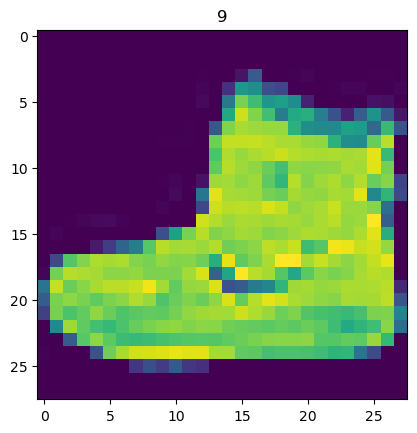

In [8]:
import matplotlib.pyplot as plt

image, label = train_data[0]
print(f' Image shape: {image.shape}')
plt.imshow(image.squeeze())
plt.title(label)

(-0.5, 27.5, 27.5, -0.5)

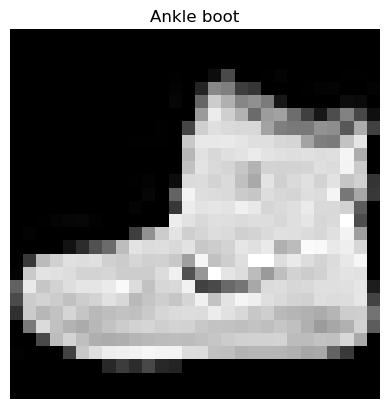

In [9]:
plt.imshow(image.squeeze(), cmap = 'gray')
plt.title(class_names[label])
plt.axis(False)

54086
50598
17733
52976
26467
38256
28887
29807
30938
51929
19912
59187
34555
26548
14140
16073


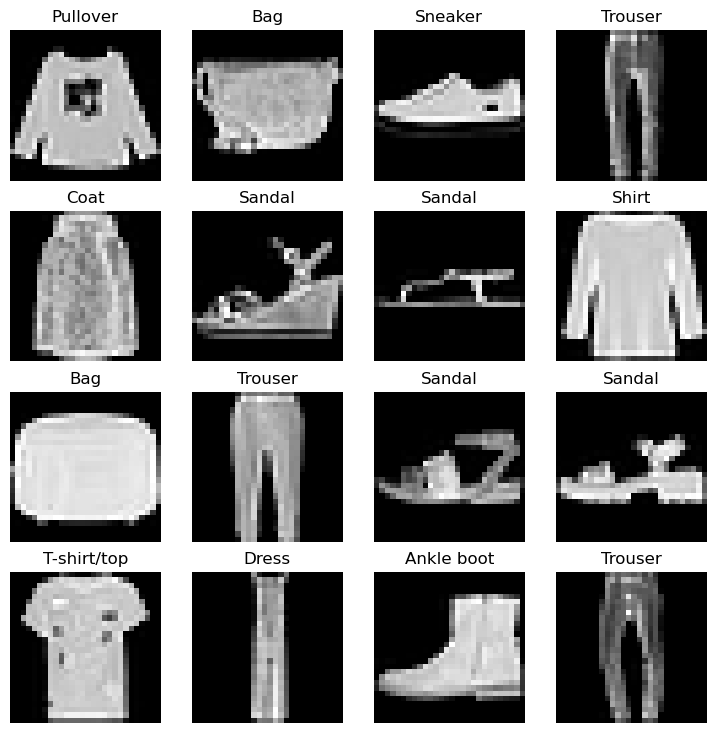

In [10]:
#torch.manual_seed(42)
fig = plt.figure (figsize= (9,9))
rows , col = 4, 4
for i in range(1, rows*col| + 1): 
    random_idx = torch.randint(0 , len(train_data) , size = [1]).item()
    print(random_idx)
    img, label = train_data[random_idx]
    fig.add_subplot(rows, col, i)
    plt.imshow(img.squeeze () , cmap = 'gray')
    plt.title(class_names[label])
    plt.axis(False)

#### 2. Prepare Dataloader

In [17]:
from torch.utils.data import DataLoader

# Setup the batch size parameters

BATCH_SIZE = 32  # We can change this

# Turn Data into batches

train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True)
                                  
                                  
test_dataloader = DataLoader(dataset = test_data, 
                             batch_size = BATCH_SIZE,
                             shuffle = False)

train_dataloader, test_dataloader    

print(f'DataLoaders : {train_dataloader, test_dataloader}')
print(f'Length of Dataloaders : {len(train_dataloader)} Batches : {BATCH_SIZE}')
print(f'Length of test_dataloader : {len(test_dataloader)} Batches {BATCH_SIZE}')
                

DataLoaders : (<torch.utils.data.dataloader.DataLoader object at 0x7ce5e5553130>, <torch.utils.data.dataloader.DataLoader object at 0x7ce5e5553a60>)
Length of Dataloaders : 1875 Batches : 32
Length of test_dataloader : 313 Batches 32


In [18]:
# To check what's inside the training dataLoader

train_features_batch , train_labels_batch = next(iter(train_dataloader))

train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

 Image ssize : torch.Size([1, 28, 28])
 Label : 7, label_size : torch.Size([])


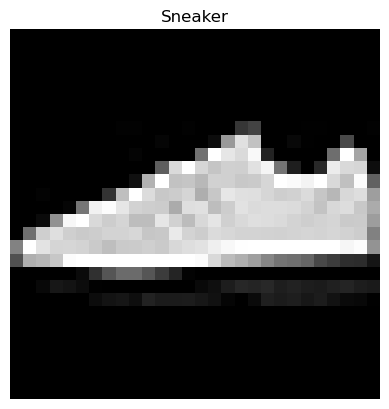

In [ ]:
# Show a sample 
#torch.manual_seed(42)

random_idx = torch.randint(0, len(train_features_batch), size = [1]).item()
img, label = train_features_batch[random_idx] , train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap = 'gray')
plt.title(class_names[label])
plt.axis(False)
print(f' Image ssize : {img.shape}')
print(f' Label : {label}, label_size : {label.shape}')
